# Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV

In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
df = pd.read_csv("../csv_files/hr_job_placement_dataset.csv")

In [4]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,2,No,1,Willing,Relevant,3.530557,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,1,yes,0,Not Willing,Relevant,9.858155,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,1,Yes,1,Willing,Relevant,5.801817,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,2,No,0,Not Willing,Relevant,2.129805,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,1,No,0,Willing,Not Relevant,7.948314,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


In [5]:
df.shape

(51500, 26)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  str    
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  str    
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  str    
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  str    
 14  r

# Null Check

In [7]:
for column in df.columns:
    if df[column].isnull().sum() != 0:
        print(column)

ssc_percentage
hsc_percentage
career_switch_willingness
relevant_experience
job_role_match
notice_period_days
layoff_history
employment_gap_months
relocation_willingness


In [8]:
numeric_columns = []
categorical_columns = []

for column in df.columns:
    if df[column].dtype == "str":
        categorical_columns.append(column)
    else:
        numeric_columns.append(column)

# Data Cleaning

## Numeric Colums - Null Imputation
- ssc_percentage
- hsc_percentage
- career_switch_willingness
- relevant_experience
- job_role_match
- notice_period_days
- layoff_history
- employment_gap_months
- relocation_willingness

#### ssc_percentage - Null Imputation

In [9]:
df["ssc_percentage"].dtype

dtype('float64')

In [10]:
df["ssc_percentage"].describe()

count    48919.000000
mean        70.002505
std          7.976314
min         50.000000
25%         64.574733
50%         69.971210
75%         75.389057
max         95.000000
Name: ssc_percentage, dtype: float64

In [11]:
df["ssc_percentage"] = df["ssc_percentage"].fillna(
    df["ssc_percentage"].mean()
)

In [12]:
df["ssc_percentage"].isnull().sum()

np.int64(0)

Missing values in the `ssc_percentage` column were filled using the `mean` value.


---

#### hsc_percentage - Null Imputation

In [13]:
df["hsc_percentage"].dtype

dtype('float64')

In [14]:
df["hsc_percentage"].describe()

count    49435.000000
mean        72.060636
std          7.916654
min         50.000000
25%         66.720058
50%         72.014383
75%         77.389894
max         95.000000
Name: hsc_percentage, dtype: float64

In [15]:
df["hsc_percentage"] = df["hsc_percentage"].fillna(
    df["hsc_percentage"].mean()
)

In [16]:
df["hsc_percentage"].isnull().sum()

np.int64(0)

Missing values in the `hsc_percentage` column were filled using the `mean` value.


---

#### career_switch_willingness - Null Imputation

In [17]:
df["career_switch_willingness"].dtypes

<StringDtype(na_value=nan)>

In [18]:
df["career_switch_willingness"].isnull().sum()

np.int64(8466)

In [19]:
df["career_switch_willingness"].value_counts()

career_switch_willingness
Not Willing    28479
Willing        14555
Name: count, dtype: int64

In [20]:
df["career_switch_willingness"] = df["career_switch_willingness"].fillna(
    df["career_switch_willingness"].mode()[0]
)

In [21]:
df["career_switch_willingness"].isnull().sum()

np.int64(0)

Missing values in the `career_switch_willingness` column were filled using the `mode` value.


---

#### relevant_experience - Null Imputation

In [22]:
df["relevant_experience"].dtypes

<StringDtype(na_value=nan)>

In [23]:
df["relevant_experience"].isnull().sum()

np.int64(8426)

In [24]:
df["relevant_experience"].value_counts()

relevant_experience
Relevant        26305
Not Relevant    16769
Name: count, dtype: int64

In [25]:
df["relevant_experience"] = df["relevant_experience"].fillna(
    df["relevant_experience"].mode()[0]
)

In [26]:
df["relevant_experience"].isnull().sum()

np.int64(0)

Missing values in the `relevant_experience` column were filled using the `mode` value.

---

#### job_role_match - Null Imputation

In [27]:
df["job_role_match"].dtypes

<StringDtype(na_value=nan)>

In [28]:
df["job_role_match"].isnull().sum()

np.int64(6131)

In [29]:
df["job_role_match"].value_counts()

job_role_match
Matched        33456
Not Matched    11913
Name: count, dtype: int64

In [30]:
df["job_role_match"] = df["job_role_match"].fillna(
    df["job_role_match"].mode()[0]
)

In [31]:
df["job_role_match"].isnull().sum()

np.int64(0)

Missing values in the `job_role_match` column were filled using the `mode` value.

---

#### notice_period_days - Null Imputation

In [32]:
df["notice_period_days"].dtypes

dtype('float64')

In [33]:
df["notice_period_days"].isnull().sum()

np.int64(1582)

In [34]:
df["notice_period_days"].describe()

count    49918.000000
mean        20.095457
std         24.852660
min          0.000000
25%          0.000000
50%         15.000000
75%         30.000000
max         90.000000
Name: notice_period_days, dtype: float64

In [35]:
df["notice_period_days"] = df["notice_period_days"].fillna(
    round(df["notice_period_days"].mean())
)

In [36]:
df["notice_period_days"].isnull().sum()

np.int64(0)

Missing values in the `notice_period_days` column were filled using the `mean` value.

---

#### layoff_history - Null Imputation

In [37]:
df["layoff_history"].dtypes

<StringDtype(na_value=nan)>

In [38]:
df["layoff_history"].isnull().sum()

np.int64(8467)

In [39]:
df["layoff_history"].value_counts()

layoff_history
No     37355
Yes     5678
Name: count, dtype: int64

In [40]:
df["layoff_history"] = df["layoff_history"].fillna(
    df["layoff_history"].mode()[0]
)

In [41]:
df["layoff_history"].isnull().sum()

np.int64(0)

Missing values in the `layoff_history` column were filled using the `mode` value.

---

#### employment_gap_months - Null Imputation

In [42]:
df["employment_gap_months"].dtypes

dtype('float64')

In [43]:
df["employment_gap_months"].isnull().sum()

np.int64(1097)

In [44]:
df["employment_gap_months"].describe()

count    50403.000000
mean         3.056187
std          4.431784
min          0.000000
25%          0.000000
50%          0.000000
75%          6.000000
max         18.000000
Name: employment_gap_months, dtype: float64

In [45]:
df["employment_gap_months"] = df["employment_gap_months"].fillna(
    round(df["employment_gap_months"].mean())
)

In [46]:
df["employment_gap_months"].isnull().sum()

np.int64(0)

Missing values in the `employment_gap_months` column were filled using the `mean` value.

---

#### relocation_willingness - Null Imputation

In [47]:
df["relocation_willingness"].dtype

<StringDtype(na_value=nan)>

In [48]:
df["relocation_willingness"].isnull().sum()

np.int64(8475)

In [49]:
df["relocation_willingness"].value_counts()

relocation_willingness
Willing        27817
Not Willing    15208
Name: count, dtype: int64

In [50]:
df["relocation_willingness"] = df["relocation_willingness"].fillna(
    df["relocation_willingness"].mode()[0]
)

In [51]:
df["relocation_willingness"].isnull().sum()

np.int64(0)

Missing values in the `relocation_willingness` column were filled using the `mode` value.

---

## Categorical Columns Cleaning

In [52]:
categorical_columns

['gender',
 'degree_specialization',
 'internship_experience',
 'career_switch_willingness',
 'relevant_experience',
 'company_tier',
 'job_role_match',
 'competition_level',
 'bond_requirement',
 'layoff_history',
 'relocation_willingness',
 'status']

In [53]:
for column in categorical_columns:
    print(df[column].value_counts())
    print()

gender
Female    24379
Male      24028
male       1549
female     1544
Name: count, dtype: int64

degree_specialization
Others                    10463
Electronics               10358
Information Technology    10298
Computer Science          10210
Mechanical                10171
Name: count, dtype: int64

internship_experience
No      25607
Yes     23327
 no      1341
yes      1225
Name: count, dtype: int64

career_switch_willingness
Not Willing    36945
Willing        14555
Name: count, dtype: int64

relevant_experience
Relevant        34731
Not Relevant    16769
Name: count, dtype: int64

company_tier
Tier 1     19046
Tier 2     18301
Tier 3     12061
Tier 1       832
Tier 2       755
Tier 3       505
Name: count, dtype: int64

job_role_match
Matched        39587
Not Matched    11913
Name: count, dtype: int64

competition_level
Low       21414
Medium    19708
High      10378
Name: count, dtype: int64

bond_requirement
Not Required    40231
Required        11269
Name: count, dtype: in

In [54]:
for column in categorical_columns:
    df[column] = df[column].str.strip().str.title()

In [55]:
for column in categorical_columns:
    print(df[column].value_counts())
    print()

gender
Female    25923
Male      25577
Name: count, dtype: int64

degree_specialization
Others                    10463
Electronics               10358
Information Technology    10298
Computer Science          10210
Mechanical                10171
Name: count, dtype: int64

internship_experience
No     26948
Yes    24552
Name: count, dtype: int64

career_switch_willingness
Not Willing    36945
Willing        14555
Name: count, dtype: int64

relevant_experience
Relevant        34731
Not Relevant    16769
Name: count, dtype: int64

company_tier
Tier 1    19878
Tier 2    19056
Tier 3    12566
Name: count, dtype: int64

job_role_match
Matched        39587
Not Matched    11913
Name: count, dtype: int64

competition_level
Low       21414
Medium    19708
High      10378
Name: count, dtype: int64

bond_requirement
Not Required    40231
Required        11269
Name: count, dtype: int64

layoff_history
No     45822
Yes     5678
Name: count, dtype: int64

relocation_willingness
Willing        36292

---

In [56]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,2,No,1,Willing,Relevant,3.530557,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,1,Yes,0,Not Willing,Relevant,9.858155,10.807739,Tier 1,Matched,High,Required,0.0,No,3.0,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,1,Yes,1,Willing,Relevant,5.801817,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,2,No,0,Not Willing,Relevant,2.129805,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,Willing,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,1,No,0,Willing,Not Relevant,7.948314,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


## Converting Columns Types 

In [57]:
df["notice_period_days"] = df["notice_period_days"].astype(int)

df["employment_gap_months"] = df["employment_gap_months"].astype(int)

Converted both `notice_period_days` and `employment_gap_months` columns into integer data types - both columns represent numerical count values.


## Changing Length of Float Values

In [58]:
for column in numeric_columns:
    if df[column].dtype == "float64":
        df[column] = round(df[column], 3)

In [1212]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.062,83.843,75.857,Computer Science,58.222,89.566,64.474,79.549,2,No,1,Willing,Relevant,3.531,5.806,Tier 3,Not Matched,Medium,Not Required,15,No,18,Not Willing,Not Placed
1,24,Male,67.886,64.973,73.094,Electronics,71.928,54.592,61.077,73.316,1,Yes,0,Not Willing,Relevant,9.858,10.808,Tier 1,Matched,High,Required,0,No,3,Not Willing,Not Placed
2,33,Female,73.892,68.834,90.196,Information Technology,72.445,58.587,79.495,75.467,1,Yes,1,Willing,Relevant,5.802,5.477,Tier 3,Not Matched,Low,Not Required,0,No,3,Not Willing,Placed
3,31,Male,74.146,76.255,75.587,Mechanical,78.856,61.022,53.740,73.676,2,No,0,Not Willing,Relevant,2.130,9.981,Tier 2,Matched,Low,Not Required,0,Yes,6,Willing,Not Placed
4,28,Male,60.476,65.786,80.801,Information Technology,68.287,65.714,61.438,88.995,1,No,0,Willing,Not Relevant,7.948,8.921,Tier 2,Matched,Medium,Not Required,0,No,3,Willing,Not Placed


---

## Remove Duplicate Records

In [59]:
df[df.duplicated()]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
50000,29,Male,82.778,55.403,72.608,Computer Science,85.730,72.426,51.770,97.578,3,Yes,3,Willing,Not Relevant,2.099,9.093,Tier 2,Matched,Medium,Not Required,15,No,0,Not Willing,Placed
50001,27,Male,54.905,80.121,77.038,Computer Science,54.166,61.549,65.307,66.014,0,Yes,0,Not Willing,Relevant,2.326,7.293,Tier 2,Matched,Low,Not Required,15,No,0,Willing,Not Placed
50002,21,Male,70.003,83.010,87.811,Others,70.505,40.000,64.535,61.854,1,No,0,Willing,Not Relevant,9.709,9.866,Tier 1,Matched,Low,Required,0,No,6,Willing,Not Placed
50003,21,Female,62.639,60.735,77.153,Computer Science,59.988,59.017,56.717,73.085,0,No,2,Not Willing,Relevant,1.025,7.109,Tier 1,Matched,Low,Not Required,0,No,0,Not Willing,Not Placed
50004,25,Male,59.361,70.230,85.378,Mechanical,65.678,83.775,79.334,80.444,4,No,3,Not Willing,Not Relevant,5.160,10.555,Tier 1,Matched,Low,Required,60,No,0,Not Willing,Not Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51495,24,Female,65.747,72.064,72.248,Electronics,55.923,73.208,69.109,63.992,2,No,0,Not Willing,Not Relevant,1.874,6.315,Tier 1,Matched,Low,Required,0,No,3,Willing,Not Placed
51496,22,Male,61.921,66.729,55.000,Others,69.525,70.246,54.960,88.514,0,Yes,1,Not Willing,Not Relevant,7.848,8.655,Tier 1,Matched,Medium,Not Required,60,No,0,Not Willing,Placed
51497,30,Male,75.578,75.718,75.048,Information Technology,73.073,58.870,71.219,79.327,1,Yes,3,Willing,Relevant,4.862,11.539,Tier 1,Matched,High,Not Required,0,No,12,Willing,Placed
51498,29,Female,77.327,56.629,69.735,Mechanical,48.270,61.172,71.650,76.319,0,Yes,0,Not Willing,Relevant,7.028,9.617,Tier 2,Matched,Medium,Not Required,0,Yes,0,Willing,Not Placed


In [60]:
df = df.drop_duplicates(keep='first')

In [61]:
df.shape

(50000, 26)

---

# Check for outliers

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  50000 non-null  int64  
 1   gender                     50000 non-null  str    
 2   ssc_percentage             50000 non-null  float64
 3   hsc_percentage             50000 non-null  float64
 4   degree_percentage          50000 non-null  float64
 5   degree_specialization      50000 non-null  str    
 6   technical_score            50000 non-null  float64
 7   aptitude_score             50000 non-null  float64
 8   communication_score        50000 non-null  float64
 9   skills_match_percentage    50000 non-null  float64
 10  certifications_count       50000 non-null  int64  
 11  internship_experience      50000 non-null  str    
 12  years_of_experience        50000 non-null  int64  
 13  career_switch_willingness  50000 non-null  str    
 14  r

In [63]:
df.describe()

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,27.506080,70.014665,72.061051,74.006590,68.034630,63.994173,66.098348,73.94074,1.400820,1.493720,4.844961,8.002052,20.105900,3.057660
std,4.026225,7.777048,7.763125,6.947612,11.855683,9.913716,9.899850,11.79933,1.185155,1.375674,2.127102,3.136701,24.470191,4.384532
min,21.000000,50.000000,50.000000,55.000000,40.000000,40.000000,45.000000,45.00000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000
25%,24.000000,64.898750,66.966750,69.297500,59.942750,57.192500,59.249750,65.86375,1.000000,0.000000,3.323000,5.669000,0.000000,0.000000
50%,27.000000,70.003000,72.061000,73.992000,67.999000,63.946500,66.024000,74.00450,1.000000,1.000000,4.807000,7.856500,15.000000,0.000000
75%,31.000000,75.078250,77.147000,78.712250,76.065250,70.703000,72.836250,82.11725,2.000000,2.000000,6.298000,10.093000,30.000000,6.000000
max,34.000000,95.000000,95.000000,95.000000,100.000000,100.000000,100.000000,100.00000,8.000000,5.000000,13.845000,26.525000,90.000000,18.000000


In [64]:
len(numeric_columns)

14

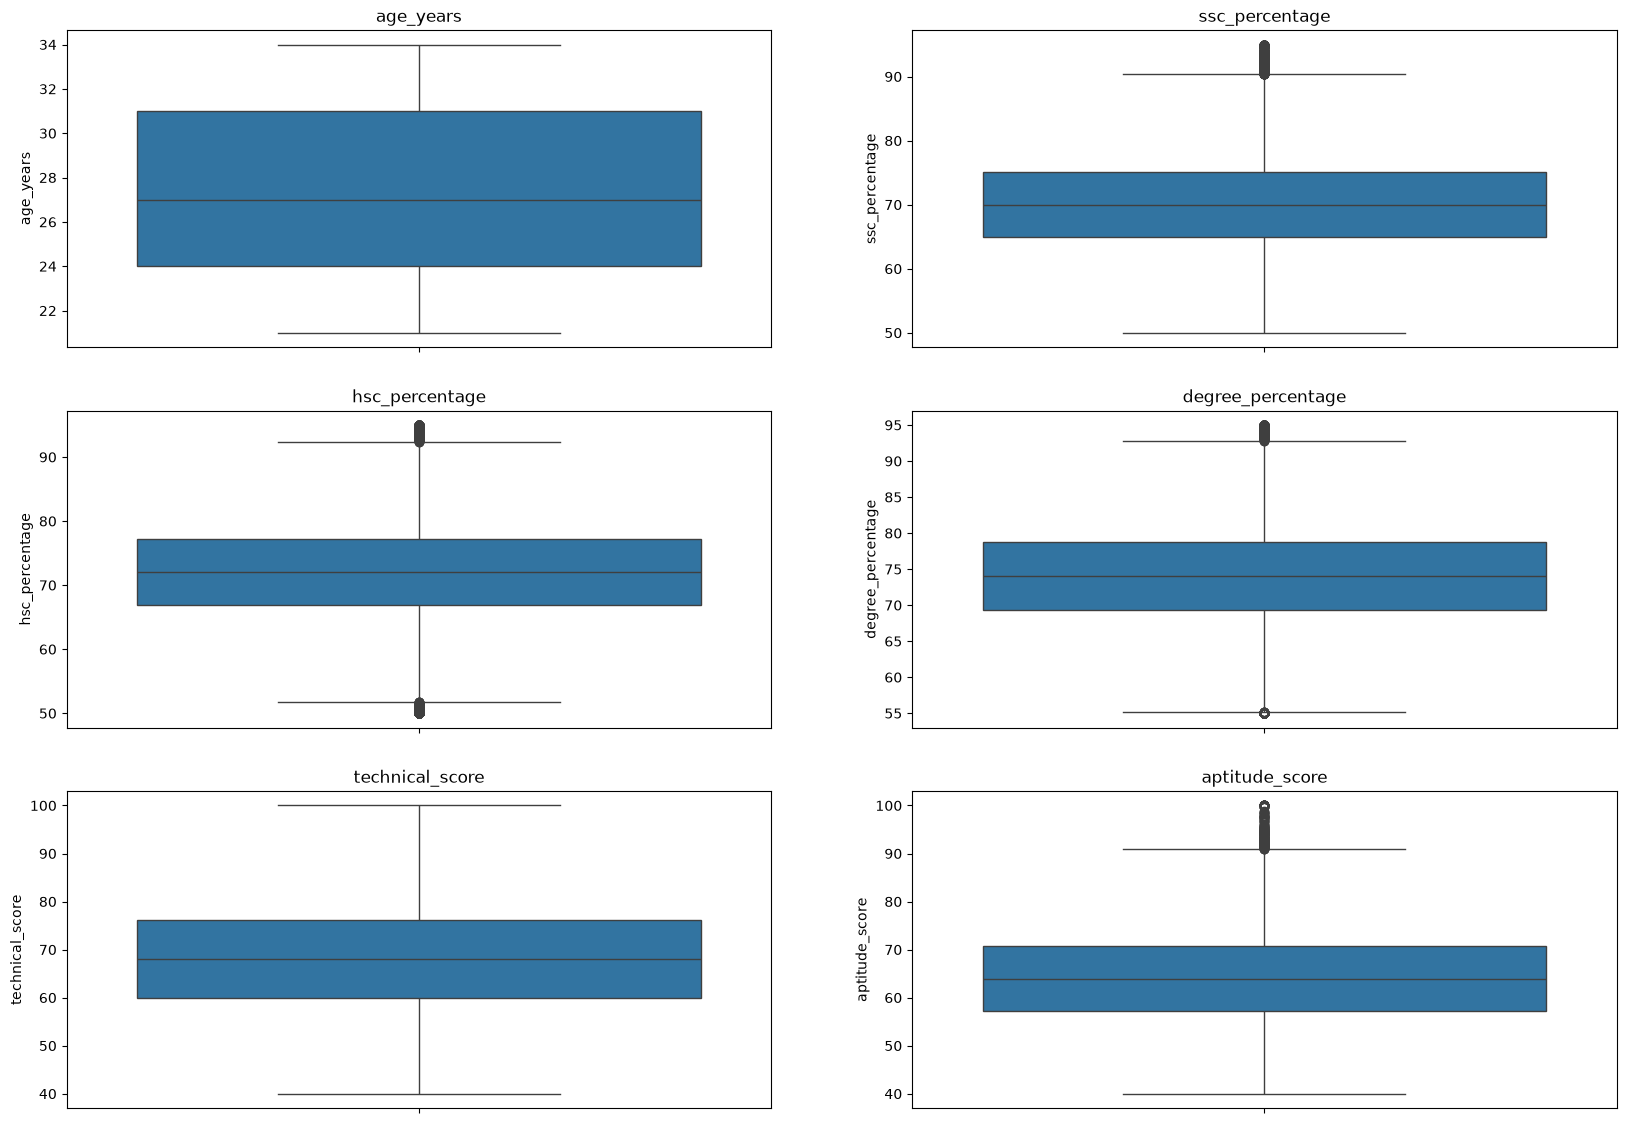

In [69]:
plt.figure(figsize=(20, 14))

for index, column in enumerate(numeric_columns[:6], 1):
    plt.subplot(3, 2, index)
    sns.boxplot(df[column])
    plt.title(column)

plt.show()

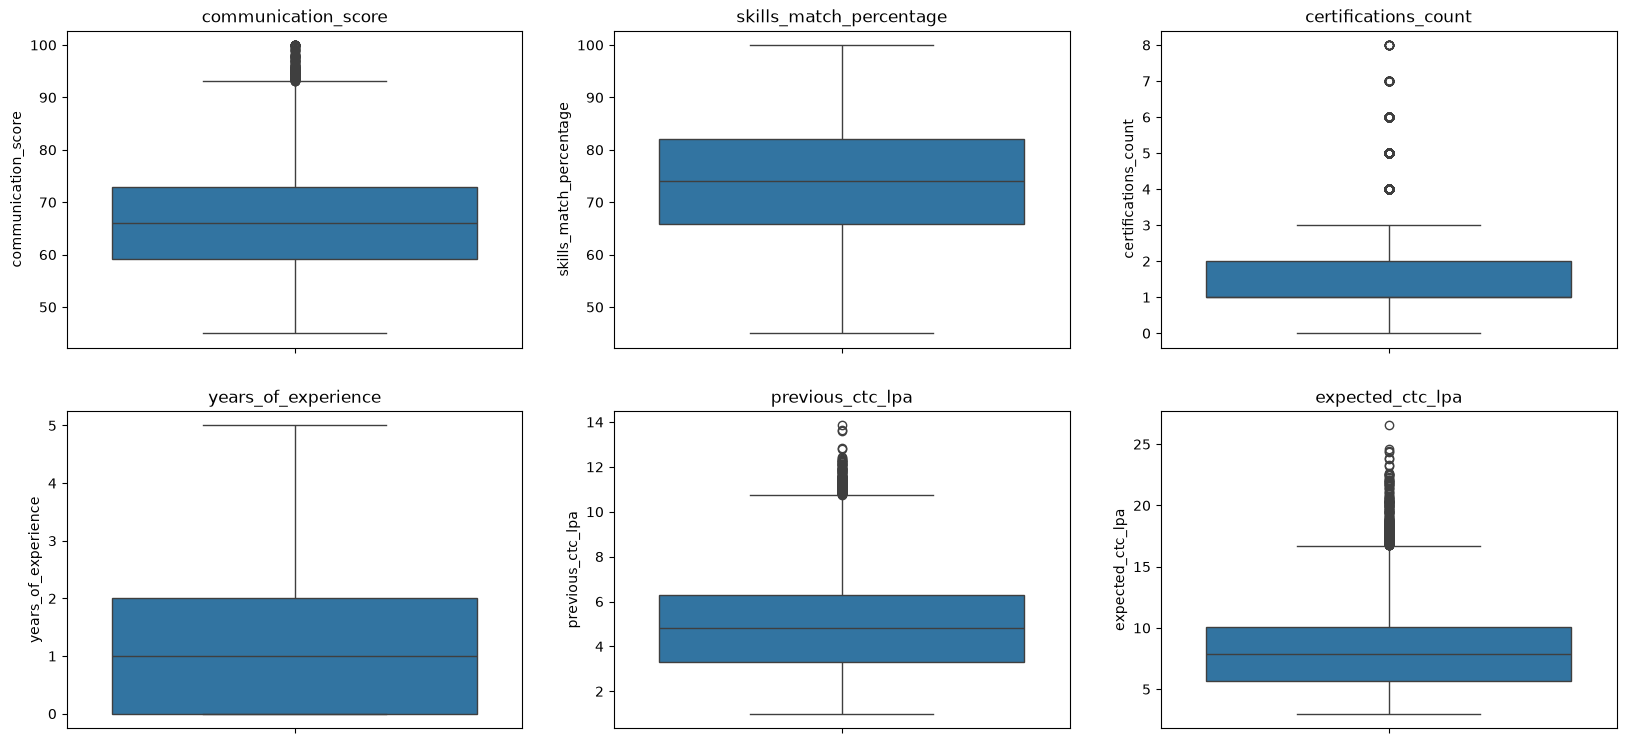

In [70]:
plt.figure(figsize=(20, 14))

for index, column in enumerate(numeric_columns[6:12], 1):
    plt.subplot(3, 3, index)
    sns.boxplot(df[column])
    plt.title(column)

plt.show()

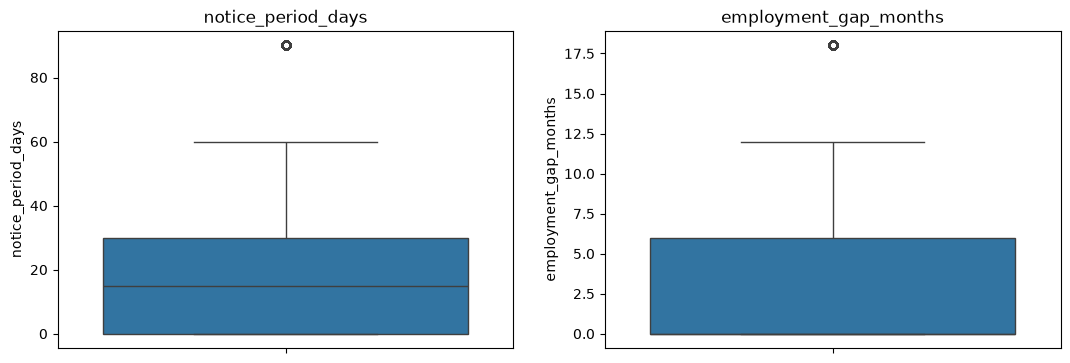

In [71]:
plt.figure(figsize=(20, 14))

for index, column in enumerate(numeric_columns[12:], 1):
    plt.subplot(3, 3, index)
    sns.boxplot(df[column])
    plt.title(column)

plt.show()

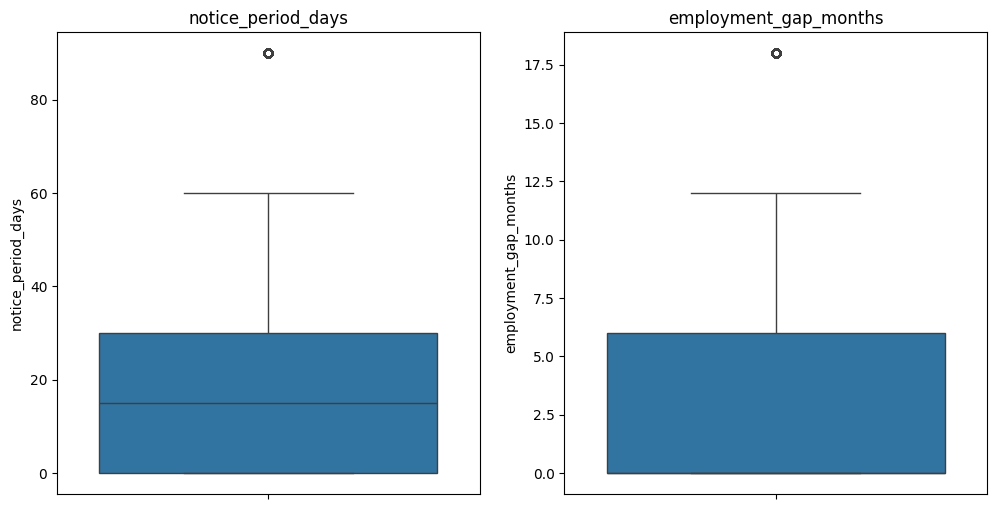

In [1222]:
plt.figure(figsize=(12, 6))

for index, column in enumerate(numeric_columns[12:], 1):
    plt.subplot(1, 2, index)
    sns.boxplot(df[column])
    plt.title(column)

plt.show()

---

In [1223]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  50000 non-null  int64  
 1   gender                     50000 non-null  str    
 2   ssc_percentage             50000 non-null  float64
 3   hsc_percentage             50000 non-null  float64
 4   degree_percentage          50000 non-null  float64
 5   degree_specialization      50000 non-null  str    
 6   technical_score            50000 non-null  float64
 7   aptitude_score             50000 non-null  float64
 8   communication_score        50000 non-null  float64
 9   skills_match_percentage    50000 non-null  float64
 10  certifications_count       50000 non-null  int64  
 11  internship_experience      50000 non-null  str    
 12  years_of_experience        50000 non-null  int64  
 13  career_switch_willingness  50000 non-null  str    
 14  r

In [1224]:
df = df.drop_duplicates(keep='first')

In [1225]:
df.shape

(50000, 26)

---

# Export CSV

In [1226]:
df.isnull().sum()

age_years                    0
gender                       0
ssc_percentage               0
hsc_percentage               0
degree_percentage            0
degree_specialization        0
technical_score              0
aptitude_score               0
communication_score          0
skills_match_percentage      0
certifications_count         0
internship_experience        0
years_of_experience          0
career_switch_willingness    0
relevant_experience          0
previous_ctc_lpa             0
expected_ctc_lpa             0
company_tier                 0
job_role_match               0
competition_level            0
bond_requirement             0
notice_period_days           0
layoff_history               0
employment_gap_months        0
relocation_willingness       0
status                       0
dtype: int64

In [1228]:
df.shape

(50000, 26)

In [1227]:
df.to_csv("../csv_files/hr_job_placement_dataset_cleaned.csv", index=False)